# 📌 Title

# Titanic Survival Prediction using Machine Learning

## CodSoft Internship - Task 1

### Author
**Anusmita Yogamaya Nayak**

---

## Project Objective

The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger information such as age, gender, passenger class, fare, and family details.

The project demonstrates the complete machine learning workflow, including data preprocessing, feature engineering, model training, prediction, and evaluation.

# 📌 Import Libraries

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Step 2: 
# Load the Dataset

In this step, we load the Titanic dataset into a Pandas DataFrame.

In [3]:
df=pd.read_csv("D:\CodeSoft\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 3:
# 📌 Explore Dataset

# Exploratory Data Analysis

Before training the model, it is important to understand the dataset by checking its structure, data types, summary statistics, and missing values.

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Step 4:
 # 📌 Data Cleaning

This step handles missing values and removes unnecessary columns to prepare the dataset for machine learning.

In [9]:
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_7272\851712005.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_7272\851712005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

# Step 5:
# Feature Selection

Remove columns that do not contribute significantly to prediction.

In [10]:
df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

# Step 6:
# Feature Encoding

Machine learning algorithms require numerical data, so categorical variables are converted into numerical form.

In [11]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Step 7:
# Define Features and Target Variable

In [12]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

# Step 8:
# Split the Dataset

The dataset is divided into training and testing sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 9:
# Train Logistic Regression Model

In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Prediction

In [15]:
y_pred = model.predict(X_test)

# Model Evaluation

The performance of the model is evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

 - Accuracy

In [16]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.8100558659217877


- Confusion Matrix

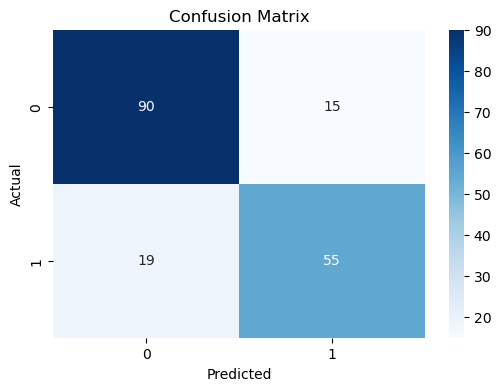

In [17]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

- Classification Report

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Conclusion

This project successfully developed a machine learning model to predict passenger survival on the Titanic dataset.

### Key Achievements

- Loaded and explored the dataset
- Cleaned missing values
- Encoded categorical variables
- Trained a Logistic Regression model
- Evaluated model performance using standard classification metrics

The project demonstrates a complete end-to-end machine learning pipeline and provides a strong foundation for predictive analytics.

# Future Scope

The project can be further improved by:

- Applying Decision Tree and Random Forest algorithms
- Performing hyperparameter tuning
- Feature engineering
- Deploying the model using Streamlit or Flask